In [1]:
import torch
import numpy as np
import shutil

from torch.utils.data import DataLoader
from cryo_ml_utils.data.cryo_ppp.dataset import CryoPPPDataset

!pip install matplotlib tqdm
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
ROOT_DIR = "/home/mzoch/data/datasets/crypppp/extracted_v2"
ds = CryoPPPDataset(
    ROOT_DIR,
    normalize_range=True,
    ctf_correction="wiener",
    datasets=["10028"],
    # temp_dir="/dev/shm",
    # copy_fn=shutil.copy,
)

In [4]:
from cryo_ml_utils.data import random_split_groups

train_ds, test_ds = random_split_groups(ds, [0.8, 0.2])

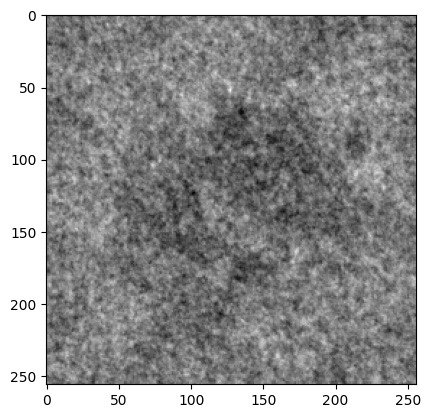

In [5]:
ds_iter = iter(train_ds)

img, particle = next(ds_iter)
plt.imshow(img[0], cmap="gray")

### Use with Data Loader

In [7]:
loader = DataLoader(
    train_ds,
    batch_size=64,
    num_workers=64,
    prefetch_factor=None,
    drop_last=False,
)
# iter(loader)

indices = []

for step, (idx, _) in tqdm(enumerate(loader)):
    indices.extend(idx.numpy().tolist())
    # if step >= len(loader):
    #     break

0it [00:00, ?it/s]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f06b137b890>>
Traceback (most recent call last):
  File "/home/mzoch/miniconda3/envs/ml-utlis/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f06b137b890>>
Traceback (most recent call last):
  File "/home/mzoch/miniconda3/envs/ml-utlis/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

  File "/home/mzoch/miniconda3/envs/ml-utlis/lib/python3.11/site-packages/torch/utils/data/_utils/signal_handling.py", line 73, in handler
    _error_if_any_worker_fails()
RuntimeError: DataLoader worker (pid 567848) exited unexpectedly with exit code 1. Details are lost 

FileNotFoundError: [Errno 2] No such file or directory